# US-Wahl 2024 – Logistische Regressionsanalyse

In diesem Projekt wird die US-Präsidentschaftswahl 2024 auf Ebene der Bundesstaaten analysiert.

Ziel ist es zu untersuchen, ob demografische und sozioökonomische Variablen dazu beitragen können, zu modellieren, ob ein Bundesstaat von Harris oder Trump gewonnen wurde.

Die Analyse umfasst:

- Datenaufbereitung
- explorative Datenanalyse
- logistische Regression
- AIC-basierte Modellselektion
- Interpretation mithilfe von Odds Ratios
- Kreuzvalidierung, ROC-Kurven und AUC

In [2]:
from __future__ import annotations

import itertools
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score


RANDOM_STATE = 123

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Hilfsfunktionen

In diesem Abschnitt werden Funktionen definiert, die im weiteren Verlauf verwendet werden:

- Bereinigung von Spaltennamen
- robustes Einlesen numerischer Werte
- logistische Regression mit `statsmodels`
- Koeffiziententabellen mit Odds Ratios
- AIC-basierte Best-Subset-Selection
- VIF-Berechnung

In [3]:
def clean_column_name(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")


def find_data_file() -> Path:
    possible_paths = [
        Path("data/US_election_2024.csv"),
        Path("US_election_2024.csv"),
        Path("data/US_election_2024_cleaned.csv"),
        Path("US_election_2024_cleaned.csv"),
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Keine CSV-Datei gefunden. Lege US_election_2024.csv oder "
        "US_election_2024_cleaned.csv entweder im Projektordner oder im Ordner data/ ab."
    )


def parse_number(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.number)):
        return value

    x = str(value).strip().replace(" ", "")

    if x == "":
        return np.nan

    if "," in x and "." in x and x.rfind(",") > x.rfind("."):
        x = x.replace(".", "").replace(",", ".")
    elif "," in x and "." in x and x.rfind(".") > x.rfind(","):
        x = x.replace(",", "")
    elif "," in x:
        x = x.replace(",", ".")

    return pd.to_numeric(x, errors="coerce")


def as_percent(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.max(skipna=True) <= 1:
        return numeric * 100
    return numeric


def fit_logit_model(data: pd.DataFrame, response: str, predictors: list[str]):
    X = data[predictors].copy()
    X = sm.add_constant(X, has_constant="add")
    y = data[response]

    model = sm.GLM(y, X, family=sm.families.Binomial())

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = model.fit(maxiter=200)

    return result


def model_bic_llf(model_result) -> float:
    n = model_result.nobs
    k = len(model_result.params)
    return -2 * model_result.llf + np.log(n) * k


def create_coefficient_table(model_result) -> pd.DataFrame:
    params = model_result.params
    bse = model_result.bse
    z_values = params / bse
    p_values = model_result.pvalues
    conf_int = model_result.conf_int()

    table = pd.DataFrame({
        "Variable": params.index,
        "Estimate": params.values,
        "Std_Error": bse.values,
        "z_value": z_values.values,
        "p_value": p_values.values,
        "CI_low": conf_int[0].values,
        "CI_high": conf_int[1].values,
    })

    table["Odds_Ratio"] = np.exp(table["Estimate"])
    table["OR_CI_low"] = np.exp(table["CI_low"])
    table["OR_CI_high"] = np.exp(table["CI_high"])

    numeric_cols = table.select_dtypes(include=[np.number]).columns
    table[numeric_cols] = table[numeric_cols].round(4)

    return table


def best_subset_selection(
    data: pd.DataFrame,
    response: str,
    predictors: list[str],
    criterion: str = "AIC",
) -> tuple[pd.DataFrame, object, list[str]]:

    if criterion not in {"AIC", "BIC"}:
        raise ValueError("criterion must be either 'AIC' or 'BIC'.")

    rows = []
    best_score = np.inf
    best_model = None
    best_predictors = None

    all_subsets = [[]]

    for k in range(1, len(predictors) + 1):
        all_subsets.extend(list(itertools.combinations(predictors, k)))

    for subset in all_subsets:
        subset = list(subset)

        try:
            if len(subset) == 0:
                X = pd.DataFrame({"const": 1}, index=data.index)
                y = data[response]
                model = sm.GLM(y, X, family=sm.families.Binomial())

                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    result = model.fit(maxiter=200)
            else:
                result = fit_logit_model(data, response, subset)

            aic = result.aic
            bic = model_bic_llf(result)

            model_name = "Intercept only" if len(subset) == 0 else " + ".join(subset)

            rows.append({
                "Model": model_name,
                "n_predictors": len(subset),
                "AIC": aic,
                "BIC": bic,
            })

            score = aic if criterion == "AIC" else bic

            if score < best_score:
                best_score = score
                best_model = result
                best_predictors = subset

        except Exception as error:
            rows.append({
                "Model": " + ".join(subset) if subset else "Intercept only",
                "n_predictors": len(subset),
                "AIC": np.nan,
                "BIC": np.nan,
                "error": str(error),
            })

    selection_table = pd.DataFrame(rows)
    selection_table = selection_table.sort_values(criterion, na_position="last").reset_index(drop=True)

    return selection_table, best_model, best_predictors


def calculate_vif(data: pd.DataFrame, predictors: list[str]) -> pd.DataFrame:
    rows = []

    for variable in predictors:
        other_variables = [v for v in predictors if v != variable]

        X = sm.add_constant(data[other_variables], has_constant="add")
        y = data[variable]

        result = sm.OLS(y, X).fit()
        r_squared = result.rsquared
        vif = 1 / (1 - r_squared)

        rows.append({
            "Variable": variable,
            "VIF": vif,
        })

    return pd.DataFrame(rows)


def make_logistic_pipeline() -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            C=1_000_000,
            solver="lbfgs",
            max_iter=10000,
            random_state=RANDOM_STATE,
        )),
    ])

## 2. Daten einlesen und vorbereiten

Die Zielvariable wird binär kodiert:

- Harris = 1
- Trump = 0

Außerdem werden `total_area` und `population` logarithmiert, da beide Variablen stark rechtsschief sind.

In [4]:
data_path = find_data_file()
print(f"Datensatz wird eingelesen aus: {data_path}")

df_raw = pd.read_csv(data_path, sep=None, engine="python", dtype=str)
df_raw.columns = [clean_column_name(col) for col in df_raw.columns]

df_raw.head()

Datensatz wird eingelesen aus: US_election_2024.csv


,state,leading_candidate,total_area,population,population_density,median_age,birth_rate,hdi,unemployment_rate,health_insurance_coverage,median_rent
0,Alabama,Trump,52420,5024279,"99,2","39,6",51,"0,877","0,04","0,915",982
1,Alaska,Trump,665384,733391,"1,3","36,5",52,"0,931","0,048","0,896",1373
2,Arizona,Trump,113990,7151502,"62,9","39,3",51,"0,906","0,043","0,901",1608
3,Arkansas,Trump,53179,3011524,"57,9","38,9",52,"0,88","0,042","0,911",933
4,California,Harris,163695,39538223,"253,7","38,2",48,"0,935","0,055","0,936",1992


In [5]:
required_columns = [
    "state",
    "leading_candidate",
    "total_area",
    "population",
    "population_density",
    "median_age",
    "birth_rate",
    "hdi",
    "unemployment_rate",
    "health_insurance_coverage",
    "median_rent",
]

missing_columns = [col for col in required_columns if col not in df_raw.columns]

if missing_columns:
    raise ValueError(f"Folgende benötigte Spalten fehlen: {missing_columns}")


numeric_variables = [
    "total_area",
    "population",
    "population_density",
    "median_age",
    "birth_rate",
    "hdi",
    "unemployment_rate",
    "health_insurance_coverage",
    "median_rent",
]

df = df_raw.copy()

for col in numeric_variables:
    df[col] = df[col].apply(parse_number)

df["state"] = df["state"].str.lower().str.strip()
df["leading_candidate"] = df["leading_candidate"].str.strip()

df["target_harris"] = np.where(df["leading_candidate"] == "Harris", 1, 0)

df["log_total_area"] = np.log(df["total_area"])
df["log_population"] = np.log(df["population"])

df["unemployment_rate_pct"] = as_percent(df["unemployment_rate"])
df["health_insurance_coverage_pct"] = as_percent(df["health_insurance_coverage"])

if df.isna().any().any():
    print(df.isna().sum()[df.isna().sum() > 0])
    raise ValueError("Der aufbereitete Datensatz enthält fehlende Werte.")

print("Anzahl Beobachtungen:", len(df))
print(df["leading_candidate"].value_counts())

df.head()

Anzahl Beobachtungen: 51
leading_candidate
Trump     31
Harris    20
Name: count, dtype: int64


,state,leading_candidate,total_area,population,population_density,median_age,birth_rate,hdi,unemployment_rate,health_insurance_coverage,median_rent,target_harris,log_total_area,log_population,unemployment_rate_pct,health_insurance_coverage_pct
0,alabama,Trump,52420,5024279,99.2,39.6,51,0.877,0.040,0.915,982,0,10.867043,15.429793,4.0,91.5
1,alaska,Trump,665384,733391,1.3,36.5,52,0.931,0.048,0.896,1373,0,13.408120,13.505434,4.8,89.6
2,arizona,Trump,113990,7151502,62.9,39.3,51,0.906,0.043,0.901,1608,0,11.643866,15.782833,4.3,90.1
3,arkansas,Trump,53179,3011524,57.9,38.9,52,0.880,0.042,0.911,933,0,10.881419,14.917957,4.2,91.1
4,california,Harris,163695,39538223,253.7,38.2,48,0.935,0.055,0.936,1992,1,12.005760,17.492778,5.5,93.6


## 3. Explorative Datenanalyse

Zunächst werden die Zielvariable und die numerischen Variablen deskriptiv betrachtet.

In [6]:
descriptive_variables = [
    "total_area",
    "population",
    "population_density",
    "median_age",
    "birth_rate",
    "hdi",
    "unemployment_rate_pct",
    "health_insurance_coverage_pct",
    "median_rent",
]

descriptive_table = df[descriptive_variables].agg([
    "mean",
    "median",
    "std",
    "min",
    "max",
]).T

descriptive_table.columns = [
    "Mittelwert",
    "Median",
    "SD",
    "Minimum",
    "Maximum",
]

descriptive_table = descriptive_table.round(4)
descriptive_table.to_csv(TABLE_DIR / "descriptive_statistics.csv")

descriptive_table

,Mittelwert,Median,SD,Minimum,Maximum
total_area,7.444596e+04,56273.000,9.693310e+04,68.000,6.653840e+05
population,6.499006e+06,4505836.000,7.408023e+06,576851.000,3.953822e+07
population_density,4.236353e+02,108.800,1.574301e+03,1.300,1.128000e+04
median_age,3.944510e+01,39.300,2.201900e+00,32.300,4.490000e+01
birth_rate,5.201960e+01,52.000,5.500900e+00,39.000,6.600000e+01
hdi,9.200000e-01,0.925,2.460000e-02,0.858,9.560000e-01
unemployment_rate_pct,3.949000e+00,4.000,7.685000e-01,2.600,5.500000e+00
health_insurance_coverage_pct,9.281570e+01,93.500,2.681500e+00,83.600,9.740000e+01
median_rent,1.299961e+03,1238.000,3.117747e+02,850.000,1.992000e+03


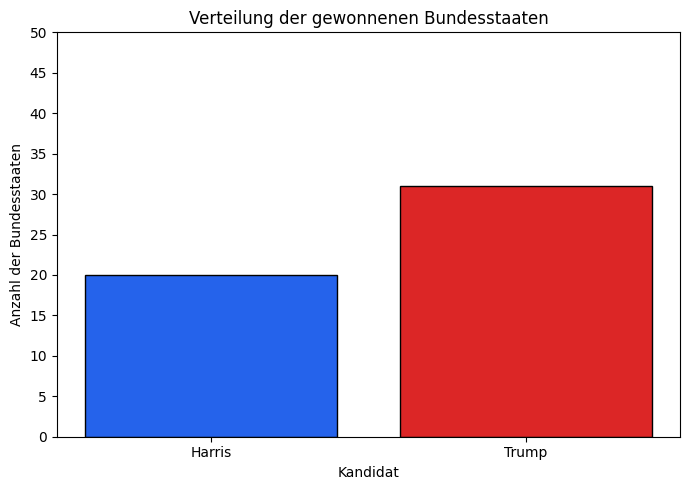

In [7]:
candidate_colors = {
    "Harris": "#2563EB",
    "Trump": "#DC2626",
}

counts = df["leading_candidate"].value_counts().reindex(["Harris", "Trump"])

plt.figure(figsize=(7, 5))
plt.bar(
    counts.index,
    counts.values,
    color=[candidate_colors[x] for x in counts.index],
    edgecolor="black"
)
plt.ylim(0, 50)
plt.yticks(range(0, 51, 5))
plt.xlabel("Kandidat")
plt.ylabel("Anzahl der Bundesstaaten")
plt.title("Verteilung der gewonnenen Bundesstaaten")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_candidate_counts.pdf")
plt.show()

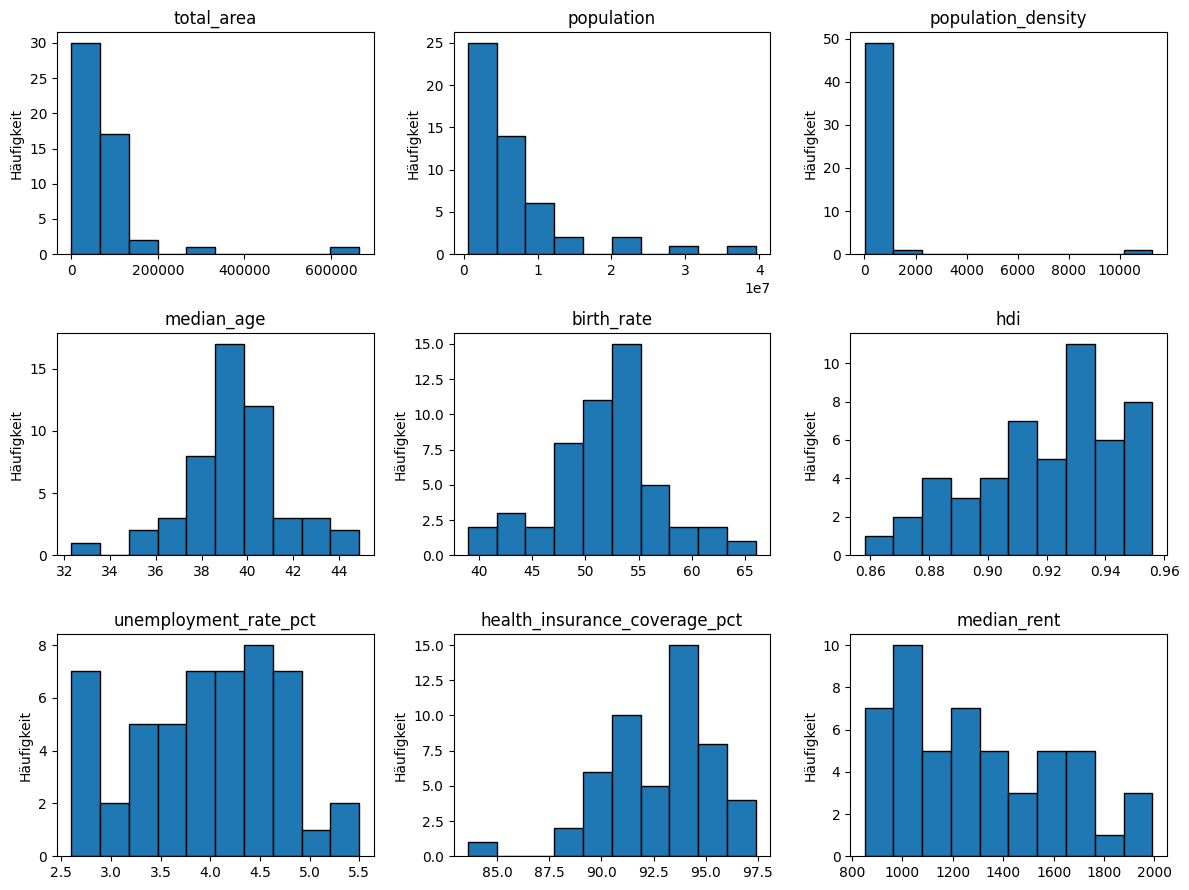

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, descriptive_variables):
    ax.hist(df[col], bins=10, edgecolor="black")
    ax.set_title(col)
    ax.set_ylabel("Häufigkeit")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_histograms.pdf")
plt.show()

C:\Users\salim\AppData\Local\Temp\ipykernel_12160\2971795142.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_harris, data_trump], labels=["Harris", "Trump"])
C:\Users\salim\AppData\Local\Temp\ipykernel_12160\2971795142.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_harris, data_trump], labels=["Harris", "Trump"])
C:\Users\salim\AppData\Local\Temp\ipykernel_12160\2971795142.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_harris, data_trump], labels=["Harris", "Trump"])
C:\Users\salim\AppData\Local\Temp\ipykernel_12160\2971795142.py:8: MatplotlibDeprecation

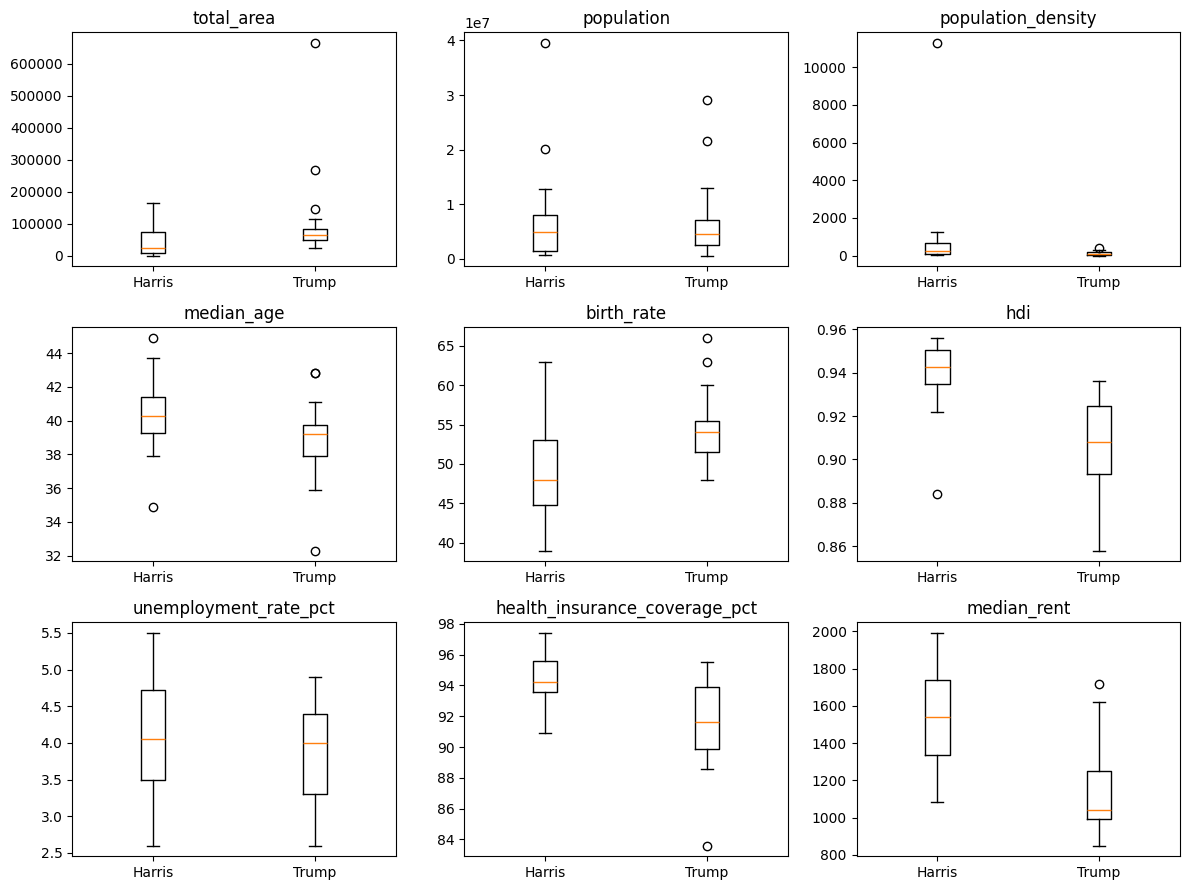

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, descriptive_variables):
    data_harris = df.loc[df["leading_candidate"] == "Harris", col]
    data_trump = df.loc[df["leading_candidate"] == "Trump", col]

    ax.boxplot([data_harris, data_trump], labels=["Harris", "Trump"])
    ax.set_title(col)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_boxplots_by_candidate.pdf")
plt.show()

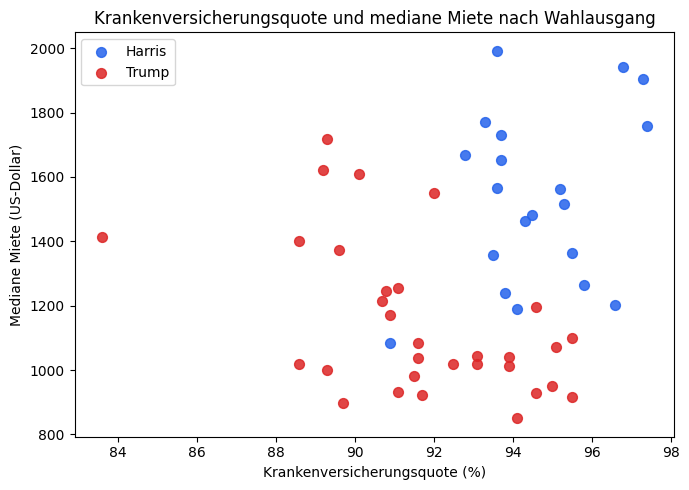

In [11]:
plt.figure(figsize=(7, 5))

for candidate in ["Harris", "Trump"]:
    subset = df[df["leading_candidate"] == candidate]
    plt.scatter(
        subset["health_insurance_coverage_pct"],
        subset["median_rent"],
        label=candidate,
        alpha=0.85,
        s=50,
        color=candidate_colors[candidate],
    )

plt.xlabel("Krankenversicherungsquote (%)")
plt.ylabel("Mediane Miete (US-Dollar)")
plt.title("Krankenversicherungsquote und mediane Miete nach Wahlausgang")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_scatter_insurance_rent.pdf")
plt.show()

## 4. Modellvariablen und Multikollinearität

Die Bevölkerungsdichte wird nicht im Hauptmodell verwendet, da sie aus Einwohnerzahl und Fläche abgeleitet ist.

Das vollständige Modell verwendet:

- log_total_area
- log_population
- median_age
- birth_rate
- hdi
- unemployment_rate_pct
- health_insurance_coverage_pct
- median_rent

In [12]:
model_predictors = [
    "log_total_area",
    "log_population",
    "median_age",
    "birth_rate",
    "hdi",
    "unemployment_rate_pct",
    "health_insurance_coverage_pct",
    "median_rent",
]

response = "target_harris"

correlation_matrix = df[model_predictors].corr().round(3)
correlation_matrix.to_csv(TABLE_DIR / "correlation_matrix.csv")

correlation_matrix

,log_total_area,log_population,median_age,birth_rate,hdi,unemployment_rate_pct,health_insurance_coverage_pct,median_rent
log_total_area,1.000,0.309,-0.209,0.404,-0.265,-0.112,-0.529,-0.280
log_population,0.309,1.000,-0.056,-0.062,-0.096,0.413,-0.198,0.268
median_age,-0.209,-0.056,1.000,-0.368,0.110,-0.148,0.309,-0.043
birth_rate,0.404,-0.062,-0.368,1.000,-0.243,-0.266,-0.375,-0.313
hdi,-0.265,-0.096,0.110,-0.243,1.000,-0.264,0.494,0.608
unemployment_rate_pct,-0.112,0.413,-0.148,-0.266,-0.264,1.000,-0.192,0.329
health_insurance_coverage_pct,-0.529,-0.198,0.309,-0.375,0.494,-0.192,1.000,0.156
median_rent,-0.280,0.268,-0.043,-0.313,0.608,0.329,0.156,1.000


## 5. Vollständiges logistisches Regressionsmodell

Das vollständige Modell enthält alle ausgewählten Prädiktoren.

Die Zielvariable ist:

- Harris = 1
- Trump = 0

In [13]:
full_model = fit_logit_model(df, response, model_predictors)

print(full_model.summary())

print("AIC vollständiges Modell:", round(full_model.aic, 3))
print("BIC vollständiges Modell:", round(model_bic_llf(full_model), 3))

                 Generalized Linear Model Regression Results                  
Dep. Variable:          target_harris   No. Observations:                   51
Model:                            GLM   Df Residuals:                       42
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8.0991
Date:                Sun, 17 May 2026   Deviance:                       16.198
Time:                        14:38:07   Pearson chi2:                     55.8
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6401
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [14]:
full_coefficients = create_coefficient_table(full_model)
full_coefficients.to_csv(TABLE_DIR / "full_model_coefficients.csv", index=False)

full_coefficients

,Variable,Estimate,Std_Error,z_value,p_value,CI_low,CI_high,Odds_Ratio,OR_CI_low,OR_CI_high
0,const,-132.5104,83.3229,-1.5903,0.1118,-295.8203,30.7995,0.000000e+00,0.0000,2.377103e+13
1,log_total_area,-1.0602,1.4948,-0.7093,0.4782,-3.9899,1.8695,3.464000e-01,0.0185,6.484900e+00
2,log_population,-1.6673,1.0708,-1.5571,0.1194,-3.7660,0.4314,1.888000e-01,0.0231,1.539300e+00
3,median_age,0.2686,0.5962,0.4505,0.6524,-0.8999,1.4371,1.308100e+00,0.4066,4.208500e+00
4,birth_rate,-0.0535,0.2768,-0.1934,0.8466,-0.5960,0.4890,9.479000e-01,0.5510,1.630600e+00
5,hdi,62.9892,61.7862,1.0195,0.3080,-58.1096,184.0879,2.269086e+27,0.0000,8.879073e+79
6,unemployment_rate_pct,2.3924,1.7330,1.3805,0.1674,-1.0042,5.7890,1.093980e+01,0.3664,3.266730e+02
7,health_insurance_coverage_pct,0.9046,0.6638,1.3626,0.1730,-0.3965,2.2057,2.470900e+00,0.6727,9.076400e+00
8,median_rent,0.0073,0.0056,1.3012,0.1932,-0.0037,0.0184,1.007400e+00,0.9963,1.018600e+00


## 6. AIC-basierte Modellselektion

Zur Reduktion der Modellkomplexität wird eine Best-Subset-Selection auf Basis des AIC durchgeführt.

Das Ziel ist ein reduziertes Modell, das eine gute Balance zwischen Anpassungsgüte und Komplexität erreicht.

In [15]:
selection_table, reduced_model, reduced_predictors = best_subset_selection(
    data=df,
    response=response,
    predictors=model_predictors,
    criterion="AIC",
)

selection_table.to_csv(TABLE_DIR / "model_selection_aic.csv", index=False)

selection_table.head(10)

,Model,n_predictors,AIC,BIC
0,log_population + median_age + unemployment_rat...,5,29.524101,41.115055
1,log_population + unemployment_rate_pct + healt...,4,29.824529,39.483657
2,log_population + birth_rate + health_insurance...,4,30.111326,39.770454
3,log_population + birth_rate + unemployment_rat...,5,30.263468,41.854421
4,log_population + median_age + health_insurance...,4,30.276106,39.935234
5,log_total_area + log_population + unemployment...,5,30.805880,42.396834
6,log_total_area + birth_rate + hdi + unemployme...,4,30.816528,40.475656
7,log_population + median_age + hdi + unemployme...,6,30.816582,44.339361
8,median_age + health_insurance_coverage_pct + m...,3,30.882244,38.609547
9,log_total_area + log_population + birth_rate +...,5,30.960406,42.551360


In [16]:
print("Ausgewähltes reduziertes Modell:")
print("target_harris ~ " + " + ".join(reduced_predictors))

print("AIC reduziertes Modell:", round(reduced_model.aic, 3))
print("BIC reduziertes Modell:", round(model_bic_llf(reduced_model), 3))

print(reduced_model.summary())

Ausgewähltes reduziertes Modell:
target_harris ~ log_population + median_age + unemployment_rate_pct + health_insurance_coverage_pct + median_rent
AIC reduziertes Modell: 29.524
BIC reduziertes Modell: 41.115
                 Generalized Linear Model Regression Results                  
Dep. Variable:          target_harris   No. Observations:                   51
Model:                            GLM   Df Residuals:                       45
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8.7621
Date:                Sun, 17 May 2026   Deviance:                       17.524
Time:                        14:38:33   Pearson chi2:                     36.9
No. Iterations:                     8   Pseudo R-squ. (CS):             0.6306
Covariance Type:            nonrobust                                         
 

In [17]:
reduced_coefficients = create_coefficient_table(reduced_model)
reduced_coefficients.to_csv(TABLE_DIR / "reduced_model_coefficients.csv", index=False)

reduced_coefficients

,Variable,Estimate,Std_Error,z_value,p_value,CI_low,CI_high,Odds_Ratio,OR_CI_low,OR_CI_high
0,const,-143.0778,52.4969,-2.7255,0.0064,-245.9699,-40.1858,0.0000,0.0000,0.0000
1,log_population,-1.6722,0.9192,-1.8193,0.0689,-3.4737,0.1293,0.1878,0.0310,1.1380
2,median_age,0.3783,0.2961,1.2779,0.2013,-0.2019,0.9586,1.4599,0.8171,2.6081
3,unemployment_rate_pct,1.8185,1.2740,1.4274,0.1535,-0.6784,4.3154,6.1625,0.5074,74.8433
4,health_insurance_coverage_pct,1.4040,0.5540,2.5344,0.0113,0.3182,2.4897,4.0713,1.3747,12.0580
5,median_rent,0.0116,0.0043,2.6760,0.0075,0.0031,0.0202,1.0117,1.0031,1.0204


## 7. Interpretation mit Odds Ratios

Die Koeffizienten der logistischen Regression werden über Odds Ratios interpretiert.

Ein Odds Ratio größer als 1 bedeutet, dass eine höhere Ausprägung der Variable mit höheren Odds für einen Harris-Sieg verbunden ist.

Ein Odds Ratio kleiner als 1 bedeutet, dass eine höhere Ausprägung der Variable mit niedrigeren Odds für einen Harris-Sieg verbunden ist.

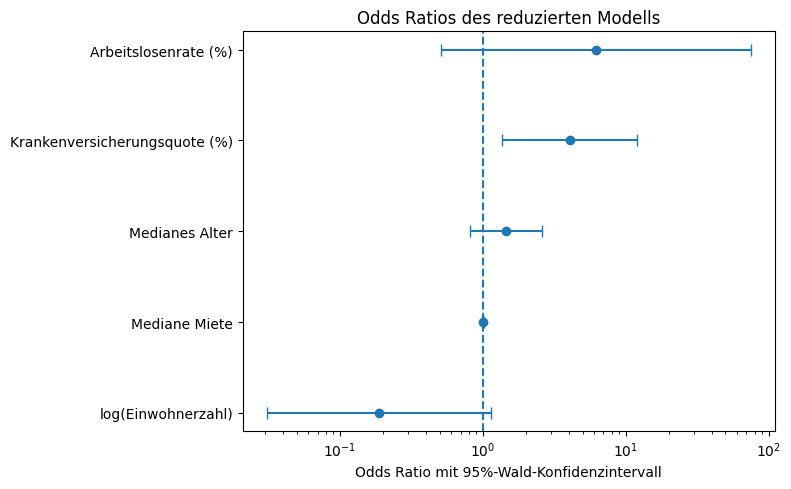

In [18]:
or_data = reduced_coefficients[reduced_coefficients["Variable"] != "const"].copy()

or_data = or_data.replace({
    "Variable": {
        "log_total_area": "log(Gesamtfläche)",
        "log_population": "log(Einwohnerzahl)",
        "median_age": "Medianes Alter",
        "birth_rate": "Geburtenrate",
        "hdi": "HDI",
        "unemployment_rate_pct": "Arbeitslosenrate (%)",
        "health_insurance_coverage_pct": "Krankenversicherungsquote (%)",
        "median_rent": "Mediane Miete",
    }
})

or_data = or_data.sort_values("Odds_Ratio")

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=or_data["Odds_Ratio"],
    y=or_data["Variable"],
    xerr=[
        or_data["Odds_Ratio"] - or_data["OR_CI_low"],
        or_data["OR_CI_high"] - or_data["Odds_Ratio"],
    ],
    fmt="o",
    capsize=4,
)

plt.axvline(1, linestyle="--")
plt.xscale("log")
plt.xlabel("Odds Ratio mit 95%-Wald-Konfidenzintervall")
plt.ylabel("")
plt.title("Odds Ratios des reduzierten Modells")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_odds_ratios_reduced_model.pdf")
plt.show()

## 8. Kreuzvalidierung und ROC/AUC

Zur Bewertung der Vorhersageleistung werden das vollständige und das reduzierte Modell mithilfe einer stratifizierten 10-fachen Kreuzvalidierung verglichen.

Die Standardisierung erfolgt innerhalb der Cross-Validation-Pipeline, um Data Leakage zu vermeiden.

In [19]:
X_full = df[model_predictors]
X_reduced = df[reduced_predictors]
y = df[response]

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE,
)

full_pipeline = make_logistic_pipeline()
reduced_pipeline = make_logistic_pipeline()

full_probs = cross_val_predict(
    full_pipeline,
    X_full,
    y,
    cv=cv,
    method="predict_proba",
)[:, 1]

reduced_probs = cross_val_predict(
    reduced_pipeline,
    X_reduced,
    y,
    cv=cv,
    method="predict_proba",
)[:, 1]

auc_full = roc_auc_score(y, full_probs)
auc_reduced = roc_auc_score(y, reduced_probs)

auc_table = pd.DataFrame({
    "Modell": ["Vollständiges Modell", "Reduziertes Modell"],
    "AUC": [auc_full, auc_reduced],
})

auc_table.to_csv(TABLE_DIR / "cross_validated_auc.csv", index=False)

auc_table

,Modell,AUC
0,Vollständiges Modell,0.837097
1,Reduziertes Modell,0.908065


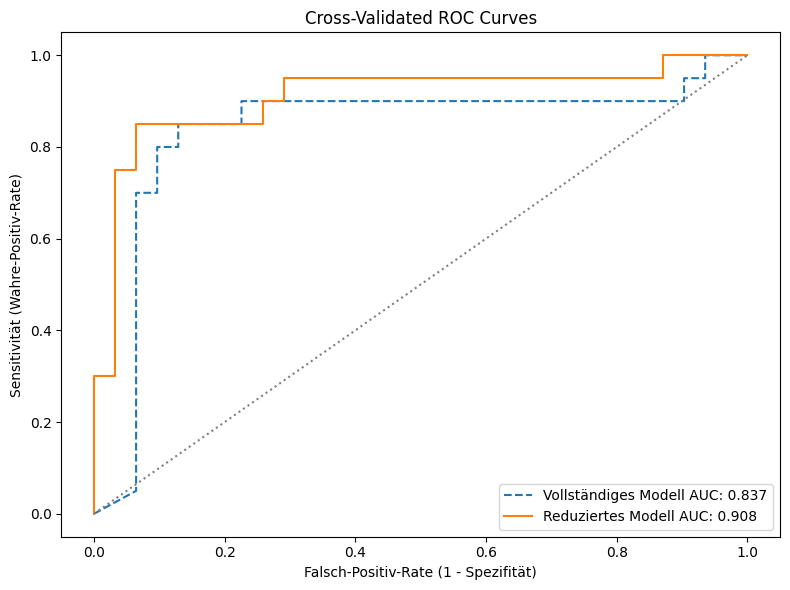

In [20]:
fpr_full, tpr_full, _ = roc_curve(y, full_probs)
fpr_reduced, tpr_reduced, _ = roc_curve(y, reduced_probs)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_full,
    tpr_full,
    linestyle="--",
    label=f"Vollständiges Modell AUC: {auc_full:.3f}"
)
plt.plot(
    fpr_reduced,
    tpr_reduced,
    linestyle="-",
    label=f"Reduziertes Modell AUC: {auc_reduced:.3f}"
)
plt.plot([0, 1], [0, 1], linestyle=":", color="gray")

plt.xlabel("Falsch-Positiv-Rate (1 - Spezifität)")
plt.ylabel("Sensitivität (Wahre-Positiv-Rate)")
plt.title("Cross-Validated ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_cross_validated_roc.pdf")
plt.show()

## 9. Ergebniszusammenfassung

Das reduzierte Modell weist sowohl einen niedrigeren AIC-Wert als auch eine höhere kreuzvalidierte AUC auf.

Damit zeigt das reduzierte Modell eine bessere Balance zwischen Modellkomplexität und Vorhersageleistung.

In [21]:
significant_variables = reduced_coefficients[
    (reduced_coefficients["Variable"] != "const")
    & (reduced_coefficients["p_value"] < 0.05)
]

print("============================================================")
print("ERGEBNISZUSAMMENFASSUNG")
print("============================================================")

print("\nZielvariable:")
print("Harris = 1, Trump = 0")

print("\nVollständiges Modell:")
print("Prädiktoren:", ", ".join(model_predictors))
print("AIC:", round(full_model.aic, 3))
print("CV-AUC:", round(auc_full, 3))

print("\nReduziertes Modell:")
print("Prädiktoren:", ", ".join(reduced_predictors))
print("AIC:", round(reduced_model.aic, 3))
print("CV-AUC:", round(auc_reduced, 3))

print("\nSignifikante Variablen im reduzierten Modell auf 5%-Niveau:")
display(significant_variables)

print("\nHinweis zur Interpretation:")
print(
    "Die Ergebnisse beschreiben Zusammenhänge auf Bundesstaatenebene. "
    "Sie erlauben keine kausalen Aussagen über individuelles Wahlverhalten."
)

ERGEBNISZUSAMMENFASSUNG

Zielvariable:
Harris = 1, Trump = 0

Vollständiges Modell:
Prädiktoren: log_total_area, log_population, median_age, birth_rate, hdi, unemployment_rate_pct, health_insurance_coverage_pct, median_rent
AIC: 34.198
CV-AUC: 0.837

Reduziertes Modell:
Prädiktoren: log_population, median_age, unemployment_rate_pct, health_insurance_coverage_pct, median_rent
AIC: 29.524
CV-AUC: 0.908

Signifikante Variablen im reduzierten Modell auf 5%-Niveau:


,Variable,Estimate,Std_Error,z_value,p_value,CI_low,CI_high,Odds_Ratio,OR_CI_low,OR_CI_high
4,health_insurance_coverage_pct,1.4040,0.5540,2.5344,0.0113,0.3182,2.4897,4.0713,1.3747,12.0580
5,median_rent,0.0116,0.0043,2.6760,0.0075,0.0031,0.0202,1.0117,1.0031,1.0204



Hinweis zur Interpretation:
Die Ergebnisse beschreiben Zusammenhänge auf Bundesstaatenebene. Sie erlauben keine kausalen Aussagen über individuelles Wahlverhalten.


## 10. Fazit

Die Analyse zeigt, dass ein reduziertes logistisches Regressionsmodell besser abschneidet als das vollständige Modell.

Das reduzierte Modell hat:

- einen niedrigeren AIC-Wert
- eine höhere kreuzvalidierte AUC
- weniger Prädiktoren
- eine bessere Interpretierbarkeit

Die wichtigsten signifikanten Prädiktoren im reduzierten Modell sind:

- Krankenversicherungsquote
- mediane Miete

Die Ergebnisse sollten als statistische Zusammenhänge auf Ebene der Bundesstaaten interpretiert werden.  
Sie erlauben keine kausalen Aussagen über individuelles Wahlverhalten.